# A — Data Cleaning & Integration Pipeline

## Qiyas Data Science / AI Hackathon
### Ethiopian Smallholder Crop-Yield Challenge

This notebook implements Deliverable A only:

- A1 — Cleaning log
- A2 — Key standardization proof
- A3 — Join map and diagram
- A4 — Join audit
- A5 — Join proof
- A6 — Feature engineering
- A7 — Integrity checks
- A8 — Master tables and data dictionary

### Data sources

1. Plot-level survey data
2. Regional monthly weather data
3. Regional/crop/year market price data

### Important methodology rules

- Raw files in `data/raw/` are never modified.
- All cleaning is performed in code.
- Train and test go through the same transformation logic.
- Statistics used for imputation are learned from training data only.
- Weather-derived features are included in the master tables.
- Market price is included for analysis/demo but must NOT be used as a yield-model feature.
- Relative paths are used throughout the project.

In [1]:
from pathlib import Path
import warnings
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Project root = parent of notebooks/
PROJECT_ROOT = Path.cwd().resolve().parent

# If the notebook is launched from project root instead:
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = Path.cwd().resolve()

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data:", RAW_DIR)
print("Processed data:", PROCESSED_DIR)
print("Reports:", REPORTS_DIR)

Project root: C:\Users\Administrator\Desktop\team_adwa
Raw data: C:\Users\Administrator\Desktop\team_adwa\data\raw
Processed data: C:\Users\Administrator\Desktop\team_adwa\data\processed
Reports: C:\Users\Administrator\Desktop\team_adwa\reports


## Load raw files

In [2]:
TRAIN_FILE = RAW_DIR / "crop_yield_train.csv"
TEST_FILE = RAW_DIR / "crop_yield_leaderboard_test.csv"
SUBMISSION_FILE = RAW_DIR / "submission_template.csv"
WEATHER_FILE = RAW_DIR / "regional_weather.csv"
PRICE_FILE = RAW_DIR / "market_prices.csv"

required_files = [
    TRAIN_FILE,
    TEST_FILE,
    SUBMISSION_FILE,
    WEATHER_FILE,
    PRICE_FILE,
]

missing_files = [str(path) for path in required_files if not path.exists()]

if missing_files:
    raise FileNotFoundError(
        "The following required files are missing:\n"
        + "\n".join(missing_files)
    )

train_raw = pd.read_csv(TRAIN_FILE)
test_raw = pd.read_csv(TEST_FILE)
submission_raw = pd.read_csv(SUBMISSION_FILE)
weather_raw = pd.read_csv(WEATHER_FILE)
price_raw = pd.read_csv(PRICE_FILE)

print("Train:", train_raw.shape)
print("Test:", test_raw.shape)
print("Submission:", submission_raw.shape)
print("Weather:", weather_raw.shape)
print("Price:", price_raw.shape)

Train: (15090, 15)
Test: (3750, 14)
Submission: (3750, 2)
Weather: (232, 6)
Price: (100, 4)


## Inspect raw schemas

In [3]:
def inspect_dataframe(name, df):
    print("=" * 80)
    print(name)
    print("=" * 80)
    print("Shape:", df.shape)
    print("\nColumns:")
    for col in df.columns:
        print(f"  - {col}: {df[col].dtype}")
    print("\nFirst 3 rows:")
    display(df.head(3))


inspect_dataframe("PLOT TRAIN", train_raw)
inspect_dataframe("PLOT TEST", test_raw)
inspect_dataframe("WEATHER", weather_raw)
inspect_dataframe("PRICE", price_raw)

PLOT TRAIN
Shape: (15090, 15)

Columns:
  - plot_id: str
  - region: str
  - crop_type: str
  - survey_year: int64
  - planting_month: str
  - altitude_m: float64
  - rainfall_mm_season: float64
  - farm_size_ha: float64
  - fertilizer_kg_per_ha: float64
  - improved_seed_used: int64
  - pest_disease_flag: int64
  - soil_quality_index: float64
  - labor_days_per_ha: float64
  - distance_to_market_km: float64
  - yield_tons_per_ha: float64

First 3 rows:


,plot_id,region,crop_type,survey_year,planting_month,altitude_m,rainfall_mm_season,farm_size_ha,fertilizer_kg_per_ha,improved_seed_used,pest_disease_flag,soil_quality_index,labor_days_per_ha,distance_to_market_km,yield_tons_per_ha
0,PLOT-000339,OROMIA,barley,2024,Aug,2697.817349,1157.403560,0.867604,29.393684,0,1,0.399408,42.678102,8.573726,2.209711
1,PLOT-007457,Amhara,Maize,2023,Jun,1523.350141,897.420122,1.099197,16.843992,1,0,0.314488,45.370495,19.928302,3.363254
2,PLOT-006092,OROMIA,wheat,2024,Feb,2389.441948,1119.155741,0.811309,41.015144,0,0,0.812596,52.846126,8.961797,3.560614


PLOT TEST
Shape: (3750, 14)

Columns:
  - plot_id: str
  - region: str
  - crop_type: str
  - survey_year: int64
  - planting_month: str
  - altitude_m: float64
  - rainfall_mm_season: float64
  - farm_size_ha: float64
  - fertilizer_kg_per_ha: float64
  - improved_seed_used: int64
  - pest_disease_flag: int64
  - soil_quality_index: float64
  - labor_days_per_ha: float64
  - distance_to_market_km: float64

First 3 rows:


,plot_id,region,crop_type,survey_year,planting_month,altitude_m,rainfall_mm_season,farm_size_ha,fertilizer_kg_per_ha,improved_seed_used,pest_disease_flag,soil_quality_index,labor_days_per_ha,distance_to_market_km
0,PLOT-017296,Oromia,barley,2024,Jul,3001.571120,NaN,0.790898,24.985712,1,0,0.464472,47.069273,24.237127
1,PLOT-017259,Amhara,sorghum,2024,Feb,1584.992004,853.355836,2.355841,31.193783,0,0,0.317168,31.602959,5.623930
2,PLOT-016178,Amhara,maize,2021,Mar,2025.148308,523.300456,1.529366,31.108711,1,1,0.590651,37.840589,10.391498


WEATHER
Shape: (232, 6)

Columns:
  - region: str
  - year: int64
  - month: str
  - avg_temp_c: float64
  - monthly_rainfall_mm: float64
  - extreme_heat_days: int64

First 3 rows:


,region,year,month,avg_temp_c,monthly_rainfall_mm,extreme_heat_days
0,Oromia,2024,Feb,18.2,78.5,0
1,Amhara,2021,Sep,15.1,271.9,0
2,Tigray,2023,May,17.8,63.1,0


PRICE
Shape: (100, 4)

Columns:
  - crop_type: str
  - region: str
  - year: int64
  - price_birr_per_quintal: float64

First 3 rows:


,crop_type,region,year,price_birr_per_quintal
0,sorghum,Amhara,2022,NaN
1,wheat,SNNPR,2023,5321.0
2,maize,Amhara,2022,2824.0


## Validate expected columns

In [4]:
expected_train_columns = {
    "plot_id",
    "region",
    "crop_type",
    "survey_year",
    "planting_month",
    "altitude_m",
    "rainfall_mm_season",
    "farm_size_ha",
    "fertilizer_kg_per_ha",
    "improved_seed_used",
    "pest_disease_flag",
    "soil_quality_index",
    "labor_days_per_ha",
    "distance_to_market_km",
    "yield_tons_per_ha",
}

expected_test_columns = expected_train_columns - {"yield_tons_per_ha"}

expected_weather_columns = {
    "region",
    "year",
    "month",
    "avg_temp_c",
    "monthly_rainfall_mm",
    "extreme_heat_days",
}

expected_price_columns = {
    "crop_type",
    "region",
    "year",
    "price_birr_per_quintal",
}

assert expected_train_columns.issubset(train_raw.columns), (
    f"Missing train columns: {expected_train_columns - set(train_raw.columns)}"
)

assert expected_test_columns.issubset(test_raw.columns), (
    f"Missing test columns: {expected_test_columns - set(test_raw.columns)}"
)

assert expected_weather_columns.issubset(weather_raw.columns), (
    f"Missing weather columns: {expected_weather_columns - set(weather_raw.columns)}"
)

assert expected_price_columns.issubset(price_raw.columns), (
    f"Missing price columns: {expected_price_columns - set(price_raw.columns)}"
)

print("PASS — expected schemas are present.")

PASS — expected schemas are present.


## A1. Create cleaning log

In [5]:
cleaning_log = []


def add_cleaning_issue(
    file_name,
    columns,
    issue_type,
    rows_affected,
    total_rows,
    fix_applied,
    why
):
    rows_affected = int(rows_affected)
    total_rows = int(total_rows)

    cleaning_log.append({
        "file": file_name,
        "columns": ", ".join(columns) if isinstance(columns, (list, tuple)) else columns,
        "issue_type": issue_type,
        "rows_affected": rows_affected,
        "percent_affected": round(
            100 * rows_affected / total_rows, 3
        ) if total_rows else 0,
        "fix_applied": fix_applied,
        "why": why,
    })


def show_cleaning_log():
    log_df = pd.DataFrame(cleaning_log)

    if log_df.empty:
        print("No issues recorded yet.")
        return log_df

    return log_df.sort_values(
        ["file", "issue_type"]
    ).reset_index(drop=True)

## General raw-data audit

In [6]:
def raw_audit(df, name):
    audit = pd.DataFrame({
        "column": df.columns,
        "dtype": [str(df[c].dtype) for c in df.columns],
        "missing_count": [df[c].isna().sum() for c in df.columns],
        "missing_pct": [
            round(df[c].isna().mean() * 100, 3)
            for c in df.columns
        ],
        "unique_count": [df[c].nunique(dropna=True) for c in df.columns],
    })

    print(f"\n{name}")
    display(audit)

    return audit


train_audit = raw_audit(train_raw, "TRAIN RAW AUDIT")
test_audit = raw_audit(test_raw, "TEST RAW AUDIT")
weather_audit = raw_audit(weather_raw, "WEATHER RAW AUDIT")
price_audit = raw_audit(price_raw, "PRICE RAW AUDIT")


TRAIN RAW AUDIT


,column,dtype,missing_count,missing_pct,unique_count
0,plot_id,str,0,0.000,15090
1,region,str,0,0.000,19
2,crop_type,str,0,0.000,21
3,survey_year,int64,0,0.000,4
4,planting_month,str,0,0.000,5
5,altitude_m,float64,0,0.000,14397
6,rainfall_mm_season,float64,449,2.975,14546
7,farm_size_ha,float64,0,0.000,14986
8,fertilizer_kg_per_ha,float64,748,4.957,14257
9,improved_seed_used,int64,0,0.000,2



TEST RAW AUDIT


,column,dtype,missing_count,missing_pct,unique_count
0,plot_id,str,0,0.000,3750
1,region,str,0,0.000,19
2,crop_type,str,0,0.000,21
3,survey_year,int64,0,0.000,4
4,planting_month,str,0,0.000,5
5,altitude_m,float64,0,0.000,3613
6,rainfall_mm_season,float64,125,3.333,3623
7,farm_size_ha,float64,0,0.000,3747
8,fertilizer_kg_per_ha,float64,189,5.040,3561
9,improved_seed_used,int64,0,0.000,2



WEATHER RAW AUDIT


,column,dtype,missing_count,missing_pct,unique_count
0,region,str,0,0.000,20
1,year,int64,0,0.000,4
2,month,str,0,0.000,12
3,avg_temp_c,float64,1,0.431,103
4,monthly_rainfall_mm,float64,2,0.862,211
5,extreme_heat_days,int64,0,0.000,22



PRICE RAW AUDIT


,column,dtype,missing_count,missing_pct,unique_count
0,crop_type,str,0,0.0,14
1,region,str,0,0.0,5
2,year,int64,0,0.0,4
3,price_birr_per_quintal,float64,4,4.0,95


## Detect sentinel values

In [7]:
def count_sentinel_rows(df, sentinel=-999):
    numeric_cols = df.select_dtypes(include=np.number).columns

    result = {}

    for col in numeric_cols:
        count = (df[col] == sentinel).sum()

        if count > 0:
            result[col] = int(count)

    return result


for name, df in {
    "crop_yield_train.csv": train_raw,
    "crop_yield_leaderboard_test.csv": test_raw,
    "regional_weather.csv": weather_raw,
    "market_prices.csv": price_raw,
}.items():

    sentinel_counts = count_sentinel_rows(df)

    print(f"\n{name}")

    if sentinel_counts:
        for col, count in sentinel_counts.items():
            print(f"  {col}: {count}")
    else:
        print("  No -999 values found.")


crop_yield_train.csv
  pest_disease_flag: 300
  labor_days_per_ha: 488

crop_yield_leaderboard_test.csv
  pest_disease_flag: 80
  labor_days_per_ha: 100

regional_weather.csv
  No -999 values found.

market_prices.csv
  No -999 values found.


## A2. Standardization dictionaries

In [8]:
REGION_MAP = {
    "oromia": "Oromia",
    "oromia region": "Oromia",
    "oromia regional state": "Oromia",

    "amhara": "Amhara",
    "amhara region": "Amhara",
    "amhara regional state": "Amhara",

    "snnpr": "SNNPR",
    "snnp": "SNNPR",
    "snn p r": "SNNPR",
    "southern nations nationalities and peoples": "SNNPR",
    "southern nations nationalities and peoples region": "SNNPR",
    "southern": "SNNPR",

    "tigray": "Tigray",
    "tigray region": "Tigray",
    "tigray regional state": "Tigray",

    "somali": "Somali",
    "somali region": "Somali",
    "somali regional state": "Somali",
}


CROP_MAP = {
    "teff": "teff",
    "tef": "teff",

    "wheat": "wheat",

    "maize": "maize",
    "corn": "maize",

    "sorghum": "sorghum",

    "barley": "barley",
}


MONTH_MAP = {
    "1": "Jan",
    "01": "Jan",
    "jan": "Jan",
    "january": "Jan",

    "2": "Feb",
    "02": "Feb",
    "feb": "Feb",
    "february": "Feb",

    "3": "Mar",
    "03": "Mar",
    "mar": "Mar",
    "march": "Mar",

    "4": "Apr",
    "04": "Apr",
    "apr": "Apr",
    "april": "Apr",

    "5": "May",
    "05": "May",
    "may": "May",

    "6": "Jun",
    "06": "Jun",
    "jun": "Jun",
    "june": "Jun",

    "7": "Jul",
    "07": "Jul",
    "jul": "Jul",
    "july": "Jul",

    "8": "Aug",
    "08": "Aug",
    "aug": "Aug",
    "august": "Aug",

    "9": "Sep",
    "09": "Sep",
    "sep": "Sep",
    "september": "Sep",

    "10": "Oct",
    "oct": "Oct",
    "october": "Oct",

    "11": "Nov",
    "nov": "Nov",
    "november": "Nov",

    "12": "Dec",
    "dec": "Dec",
    "december": "Dec",
}

MONTH_ORDER = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

ALLOWED_REGIONS = {
    "Oromia",
    "Amhara",
    "SNNPR",
    "Tigray",
    "Somali",
}

ALLOWED_CROPS = {
    "teff",
    "wheat",
    "maize",
    "sorghum",
    "barley",
}

## Helper functions for standardization

In [9]:
def normalize_text(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip().lower()

    # Normalize repeated whitespace
    value = " ".join(value.split())

    return value


def standardize_region(series):
    normalized = series.map(normalize_text)

    return normalized.map(REGION_MAP)


def standardize_crop(series):
    normalized = series.map(normalize_text)

    return normalized.map(CROP_MAP)


def standardize_month(series):
    normalized = series.map(normalize_text)

    return normalized.map(MONTH_MAP)

## A2: before/after key values

In [10]:
def show_before_after(name, before, after):
    before_values = sorted(
        pd.Series(before.dropna().astype(str).unique()).tolist()
    )

    after_values = sorted(
        pd.Series(after.dropna().astype(str).unique()).tolist()
    )

    print("=" * 80)
    print(name)
    print("=" * 80)

    print("\nBEFORE:")
    print(before_values)

    print("\nAFTER:")
    print(after_values)


show_before_after(
    "TRAIN REGION",
    train_raw["region"],
    standardize_region(train_raw["region"])
)

show_before_after(
    "WEATHER REGION",
    weather_raw["region"],
    standardize_region(weather_raw["region"])
)

show_before_after(
    "PRICE REGION",
    price_raw["region"],
    standardize_region(price_raw["region"])
)

show_before_after(
    "TRAIN CROP",
    train_raw["crop_type"],
    standardize_crop(train_raw["crop_type"])
)

show_before_after(
    "PRICE CROP",
    price_raw["crop_type"],
    standardize_crop(price_raw["crop_type"])
)

TRAIN REGION

BEFORE:
['AMHARA', 'Amhara', 'Amhara ', 'OROMIA', 'Oromia', 'Oromia ', 'SNNPR', 'SNNPR ', 'SOMALI', 'Somali', 'Somali ', 'TIGRAY', 'Tigray', 'Tigray ', 'amhara', 'oromia', 'snnpr', 'somali', 'tigray']

AFTER:
['Amhara', 'Oromia', 'SNNPR', 'Somali', 'Tigray']
WEATHER REGION

BEFORE:
['AMH', 'Amhara', 'Amhara ', 'ORO', 'Oromia', 'Oromia ', 'SNNP', 'SNNPR', 'SNNPR ', 'SOM', 'Somali', 'Somali ', 'TIG', 'Tigray', 'Tigray ', 'amhara', 'oromia', 'snnpr', 'somali', 'tigray']

AFTER:
['Amhara', 'Oromia', 'SNNPR', 'Somali', 'Tigray']
PRICE REGION

BEFORE:
['Amhara', 'Oromia', 'SNNPR', 'Somali', 'Tigray']

AFTER:
['Amhara', 'Oromia', 'SNNPR', 'Somali', 'Tigray']
TRAIN CROP

BEFORE:
[' barley ', ' maize ', ' sorghum ', ' teff ', ' wheat ', 'BARLEY', 'Barley', 'MAIZE', 'Maize', 'SORGHUM', 'Sorghum', 'TEFF', 'Tef', 'Teff', 'WHEAT', 'Wheat', 'barley', 'maize', 'sorghum', 'teff', 'wheat']

AFTER:
['barley', 'maize', 'sorghum', 'teff', 'wheat']
PRICE CROP

BEFORE:
[' barley ', ' maize ', 

## Make working copies

In [11]:
train = train_raw.copy()
test = test_raw.copy()
weather = weather_raw.copy()
prices = price_raw.copy()

## Standardize categorical columns

In [12]:
# Keep original values for audit
train_region_before = train["region"].copy()
test_region_before = test["region"].copy()
weather_region_before = weather["region"].copy()
prices_region_before = prices["region"].copy()

train_crop_before = train["crop_type"].copy()
test_crop_before = test["crop_type"].copy()
prices_crop_before = prices["crop_type"].copy()

train["region"] = standardize_region(train["region"])
test["region"] = standardize_region(test["region"])
weather["region"] = standardize_region(weather["region"])
prices["region"] = standardize_region(prices["region"])

train["crop_type"] = standardize_crop(train["crop_type"])
test["crop_type"] = standardize_crop(test["crop_type"])
prices["crop_type"] = standardize_crop(prices["crop_type"])

train["planting_month"] = standardize_month(train["planting_month"])
weather["month"] = standardize_month(weather["month"])

## Record inconsistent-label issues

In [13]:
def count_changed(before, after):
    before_norm = before.map(normalize_text)
    after_norm = after.map(normalize_text)

    return int((before_norm != after_norm).fillna(False).sum())


region_changes_plot = (
    count_changed(train_region_before, train["region"])
    + count_changed(test_region_before, test["region"])
)

region_changes_weather = count_changed(
    weather_region_before,
    weather["region"]
)

region_changes_price = count_changed(
    prices_region_before,
    prices["region"]
)

crop_changes_plot = (
    count_changed(train_crop_before, train["crop_type"])
    + count_changed(test_crop_before, test["crop_type"])
)

crop_changes_price = count_changed(
    prices_crop_before,
    prices["crop_type"]
)

add_cleaning_issue(
    "crop_yield_train.csv + crop_yield_leaderboard_test.csv",
    ["region", "crop_type", "planting_month"],
    "inconsistent categorical labels",
    region_changes_plot + crop_changes_plot,
    len(train) + len(test),
    "Trimmed/lowercased labels and mapped known aliases to canonical labels.",
    "Required identical category labels across train, test, weather, and price tables."
)

add_cleaning_issue(
    "regional_weather.csv",
    ["region", "month"],
    "inconsistent categorical labels",
    region_changes_weather,
    len(weather),
    "Standardized region and month labels.",
    "Required reliable region/year/month weather joins."
)

add_cleaning_issue(
    "market_prices.csv",
    ["region", "crop_type"],
    "inconsistent categorical labels",
    region_changes_price + crop_changes_price,
    len(prices),
    "Standardized region and crop labels.",
    "Required reliable price joins."
)

## Numeric conversion

In [14]:
plot_numeric_columns = [
    "survey_year",
    "altitude_m",
    "rainfall_mm_season",
    "farm_size_ha",
    "fertilizer_kg_per_ha",
    "improved_seed_used",
    "pest_disease_flag",
    "soil_quality_index",
    "labor_days_per_ha",
    "distance_to_market_km",
]

weather_numeric_columns = [
    "year",
    "avg_temp_c",
    "monthly_rainfall_mm",
    "extreme_heat_days",
]

price_numeric_columns = [
    "year",
    "price_birr_per_quintal",
]


for col in plot_numeric_columns:
    train[col] = pd.to_numeric(train[col], errors="coerce")
    test[col] = pd.to_numeric(test[col], errors="coerce")

train["yield_tons_per_ha"] = pd.to_numeric(
    train["yield_tons_per_ha"],
    errors="coerce"
)

for col in weather_numeric_columns:
    weather[col] = pd.to_numeric(
        weather[col],
        errors="coerce"
    )

for col in price_numeric_columns:
    prices[col] = pd.to_numeric(
        prices[col],
        errors="coerce"
    )

## Convert -999 to missing

In [15]:
all_numeric_working = [
    train,
    test,
    weather,
    prices,
]

sentinel_total = {}

for df in all_numeric_working:
    numeric_cols = df.select_dtypes(include=np.number).columns

    for col in numeric_cols:
        count = int((df[col] == -999).sum())

        if count > 0:
            sentinel_total[col] = sentinel_total.get(col, 0) + count

        df.loc[df[col] == -999, col] = np.nan

print("Sentinel values converted to NaN:")
print(sentinel_total)

Sentinel values converted to NaN:
{'pest_disease_flag': 380, 'labor_days_per_ha': 588}


## Record sentinel issue

In [16]:
for file_name, df in {
    "crop_yield_train.csv": train,
    "regional_weather.csv": weather,
    "market_prices.csv": prices,
}.items():

    numeric_cols = df.select_dtypes(include=np.number).columns

    # This counts missing values caused by -999 only if
    # the original raw data contained them.
    original_df = {
        "crop_yield_train.csv": train_raw,
        "regional_weather.csv": weather_raw,
        "market_prices.csv": price_raw,
    }[file_name]

    count = 0

    for col in original_df.select_dtypes(include=np.number).columns:
        count += int((original_df[col] == -999).sum())

    if count > 0:
        add_cleaning_issue(
            file_name,
            list(numeric_cols),
            "sentinel values (-999)",
            count,
            len(original_df),
            "Converted -999 to NaN before validation/imputation.",
            "-999 is a missing-value sentinel, not a valid measurement."
        )

## Detect duplicate rows

In [17]:
duplicate_counts = {
    "crop_yield_train.csv": int(train.duplicated().sum()),
    "crop_yield_leaderboard_test.csv": int(test.duplicated().sum()),
    "regional_weather.csv": int(weather.duplicated().sum()),
    "market_prices.csv": int(prices.duplicated().sum()),
}

duplicate_counts

{'crop_yield_train.csv': 0,
 'crop_yield_leaderboard_test.csv': 0,
 'regional_weather.csv': 1,
 'market_prices.csv': 0}

## Remove exact duplicate rows

In [18]:
for name, df in [
    ("crop_yield_train.csv", train),
    ("crop_yield_leaderboard_test.csv", test),
    ("regional_weather.csv", weather),
    ("market_prices.csv", prices),
]:

    before = len(df)

    df.drop_duplicates(inplace=True)

    removed = before - len(df)

    if removed > 0:
        add_cleaning_issue(
            name,
            list(df.columns),
            "duplicate rows",
            removed,
            before,
            "Removed exact duplicate rows.",
            "Duplicate records can distort aggregation and model training."
        )

## Detect impossible plot values

In [19]:
plot_invalid_masks = {}

plot_invalid_masks["survey_year"] = ~train["survey_year"].between(
    2021, 2024, inclusive="both"
)

plot_invalid_masks["farm_size_ha"] = (
    train["farm_size_ha"].notna()
    & (train["farm_size_ha"] <= 0)
)

plot_invalid_masks["rainfall_mm_season"] = (
    train["rainfall_mm_season"].notna()
    & (train["rainfall_mm_season"] < 0)
)

plot_invalid_masks["fertilizer_kg_per_ha"] = (
    train["fertilizer_kg_per_ha"].notna()
    & (train["fertilizer_kg_per_ha"] < 0)
)

plot_invalid_masks["soil_quality_index"] = (
    train["soil_quality_index"].notna()
    & ~train["soil_quality_index"].between(0, 1)
)

plot_invalid_masks["labor_days_per_ha"] = (
    train["labor_days_per_ha"].notna()
    & (train["labor_days_per_ha"] < 0)
)

plot_invalid_masks["distance_to_market_km"] = (
    train["distance_to_market_km"].notna()
    & (train["distance_to_market_km"] < 0)
)

plot_invalid_masks["yield_tons_per_ha"] = (
    train["yield_tons_per_ha"].notna()
    & (train["yield_tons_per_ha"] < 0)
)

plot_invalid_masks["improved_seed_used"] = (
    train["improved_seed_used"].notna()
    & ~train["improved_seed_used"].isin([0, 1])
)

plot_invalid_masks["pest_disease_flag"] = (
    train["pest_disease_flag"].notna()
    & ~train["pest_disease_flag"].isin([0, 1])
)

for column, mask in plot_invalid_masks.items():
    count = int(mask.sum())

    if count > 0:
        add_cleaning_issue(
            "crop_yield_train.csv",
            [column],
            "impossible numeric/category values",
            count,
            len(train),
            "Set implausible values to NaN and later impute using train-derived statistics.",
            "Impossible measurements cannot be used as valid observations."
        )

        train.loc[mask, column] = np.nan

## Apply equivalent invalid-value handling to test

In [20]:
test_invalid_rules = {
    "survey_year": lambda s: ~s.between(2021, 2024, inclusive="both"),
    "farm_size_ha": lambda s: s.notna() & (s <= 0),
    "rainfall_mm_season": lambda s: s.notna() & (s < 0),
    "fertilizer_kg_per_ha": lambda s: s.notna() & (s < 0),
    "soil_quality_index": lambda s: s.notna() & ~s.between(0, 1),
    "labor_days_per_ha": lambda s: s.notna() & (s < 0),
    "distance_to_market_km": lambda s: s.notna() & (s < 0),
    "improved_seed_used": lambda s: s.notna() & ~s.isin([0, 1]),
    "pest_disease_flag": lambda s: s.notna() & ~s.isin([0, 1]),
}

for column, rule in test_invalid_rules.items():
    mask = rule(test[column])

    count = int(mask.sum())

    if count > 0:
        add_cleaning_issue(
            "crop_yield_leaderboard_test.csv",
            [column],
            "impossible numeric/category values",
            count,
            len(test),
            "Set implausible values to NaN; values are later imputed using train-derived statistics.",
            "The same cleaning logic must be applied to test data."
        )

        test.loc[mask, column] = np.nan

## Weather validation

In [21]:
weather_invalid = {
    "year": ~weather["year"].between(2021, 2024, inclusive="both"),
    "avg_temp_c": (
        weather["avg_temp_c"].notna()
        & ~weather["avg_temp_c"].between(-20, 60)
    ),
    "monthly_rainfall_mm": (
        weather["monthly_rainfall_mm"].notna()
        & (weather["monthly_rainfall_mm"] < 0)
    ),
    "extreme_heat_days": (
        weather["extreme_heat_days"].notna()
        & (weather["extreme_heat_days"] < 0)
    ),
}

for column, mask in weather_invalid.items():

    count = int(mask.sum())

    if count > 0:
        add_cleaning_issue(
            "regional_weather.csv",
            [column],
            "invalid weather values",
            count,
            len(weather),
            "Set implausible values to NaN before seasonal aggregation.",
            "Impossible weather measurements would contaminate seasonal features."
        )

        weather.loc[mask, column] = np.nan

## Weather duplicate join keys

The weather table must ultimately have one record per:
region + year + month

In [22]:
weather_key = ["region", "year", "month"]

weather_duplicate_keys = (
    weather.groupby(weather_key)
    .size()
    .reset_index(name="count")
)

weather_duplicate_keys = weather_duplicate_keys[
    weather_duplicate_keys["count"] > 1
]

print(
    "Duplicate region/year/month keys:",
    len(weather_duplicate_keys)
)

display(weather_duplicate_keys.head(20))

Duplicate region/year/month keys: 5


,region,year,month,count
19,Amhara,2022.0,Sep,2
89,SNNPR,2021.0,Jul,2
148,Somali,2022.0,Jun,2
166,Somali,2024.0,Feb,2
174,Tigray,2021.0,Feb,2


## Aggregate duplicate weather readings

In [23]:
if len(weather_duplicate_keys) > 0:

    duplicate_rows = weather.merge(
        weather_duplicate_keys[weather_key],
        on=weather_key,
        how="inner"
    )

    add_cleaning_issue(
        "regional_weather.csv",
        weather_key,
        "duplicate weather keys",
        len(duplicate_rows),
        len(weather),
        "Aggregated duplicate readings by mean for numeric weather variables.",
        "The weather join requires one region/year/month record."
    )

weather = (
    weather
    .groupby(weather_key, as_index=False)
    .agg({
        "avg_temp_c": "mean",
        "monthly_rainfall_mm": "mean",
        "extreme_heat_days": "mean",
    })
)

## Price validation

In [24]:
price_invalid = (
    prices["price_birr_per_quintal"].notna()
    & (prices["price_birr_per_quintal"] <= 0)
)

count_invalid_price = int(price_invalid.sum())

if count_invalid_price > 0:

    add_cleaning_issue(
        "market_prices.csv",
        ["price_birr_per_quintal"],
        "non-positive price values",
        count_invalid_price,
        len(prices),
        "Set non-positive prices to NaN.",
        "Market prices must be positive."
    )

    prices.loc[price_invalid, "price_birr_per_quintal"] = np.nan

## Price duplicate keys

In [25]:
price_key = ["crop_type", "region", "year"]

price_duplicate_keys = (
    prices.groupby(price_key)
    .size()
    .reset_index(name="count")
)

price_duplicate_keys = price_duplicate_keys[
    price_duplicate_keys["count"] > 1
]

print(
    "Duplicate price keys:",
    len(price_duplicate_keys)
)

display(price_duplicate_keys.head(20))

Duplicate price keys: 0


,crop_type,region,year,count


## Resolve duplicate prices

In [26]:
if len(price_duplicate_keys) > 0:

    duplicate_price_rows = prices.merge(
        price_duplicate_keys[price_key],
        on=price_key,
        how="inner"
    )

    add_cleaning_issue(
        "market_prices.csv",
        price_key,
        "duplicate price keys",
        len(duplicate_price_rows),
        len(prices),
        "Aggregated duplicate prices by median within crop/region/year.",
        "The price join must be many-to-one from plot to price."
    )

prices = (
    prices
    .groupby(price_key, as_index=False)
    .agg({
        "price_birr_per_quintal": "median"
    })
)

## Detect suspicious price unit values

In [27]:
# Compare each price against the median price for the same crop/year.
crop_year_median = (
    prices.groupby(["crop_type", "year"])["price_birr_per_quintal"]
    .transform("median")
)

prices["price_ratio_to_crop_year_median"] = (
    prices["price_birr_per_quintal"] / crop_year_median
)

suspicious_high = (
    prices["price_ratio_to_crop_year_median"] >= 5
)

suspicious_low = (
    prices["price_ratio_to_crop_year_median"] <= 0.2
)

suspicious_prices = prices[
    suspicious_high | suspicious_low
].copy()

print(
    "Potential unit-anomaly price rows:",
    len(suspicious_prices)
)

display(
    suspicious_prices[
        [
            "crop_type",
            "region",
            "year",
            "price_birr_per_quintal",
            "price_ratio_to_crop_year_median",
        ]
    ]
)

Potential unit-anomaly price rows: 4


,crop_type,region,year,price_birr_per_quintal,price_ratio_to_crop_year_median
0,barley,Amhara,2021.0,41.0,0.010919
43,sorghum,Amhara,2024.0,34.0,0.009706
81,wheat,Amhara,2022.0,49.0,0.010701
92,wheat,Somali,2021.0,44.0,0.009980


## Correct high-confidence 10× unit anomalies

In [28]:
def nearest_unit_factor(ratio):
    """
    Return correction factor only for strong approximately-10x anomalies.
    
    factor = 0.1 means divide by 10
    factor = 10 means multiply by 10
    None means no automatic correction.
    """
    if pd.isna(ratio):
        return None

    if 8 <= ratio <= 12:
        return 0.1

    if 0.08 <= ratio <= 0.12:
        return 10.0

    return None


prices["unit_correction_factor"] = (
    prices["price_ratio_to_crop_year_median"]
    .map(nearest_unit_factor)
)

unit_anomaly_mask = prices["unit_correction_factor"].notna()

unit_anomaly_count = int(unit_anomaly_mask.sum())

if unit_anomaly_count > 0:

    add_cleaning_issue(
        "market_prices.csv",
        ["price_birr_per_quintal"],
        "suspected 10x unit mix-up",
        unit_anomaly_count,
        len(prices),
        "Applied a 10x correction only when the price was approximately 10 times or one-tenth of the crop/year median.",
        "The source instructions identify a unit mix-up; the correction is based on a transparent data-derived rule."
    )

    prices.loc[unit_anomaly_mask, "price_birr_per_quintal"] = (
        prices.loc[unit_anomaly_mask, "price_birr_per_quintal"]
        * prices.loc[unit_anomaly_mask, "unit_correction_factor"]
    )

# Remove diagnostic columns before joining.
prices.drop(
    columns=[
        "price_ratio_to_crop_year_median",
        "unit_correction_factor",
    ],
    inplace=True
)

print("Corrected unit anomalies:", unit_anomaly_count)

Corrected unit anomalies: 0


## Final category validation

In [29]:
unknown_train_regions = set(train["region"].dropna()) - ALLOWED_REGIONS
unknown_test_regions = set(test["region"].dropna()) - ALLOWED_REGIONS
unknown_weather_regions = set(weather["region"].dropna()) - ALLOWED_REGIONS
unknown_price_regions = set(prices["region"].dropna()) - ALLOWED_REGIONS

unknown_train_crops = set(train["crop_type"].dropna()) - ALLOWED_CROPS
unknown_test_crops = set(test["crop_type"].dropna()) - ALLOWED_CROPS
unknown_price_crops = set(prices["crop_type"].dropna()) - ALLOWED_CROPS

print("Unknown train regions:", unknown_train_regions)
print("Unknown test regions:", unknown_test_regions)
print("Unknown weather regions:", unknown_weather_regions)
print("Unknown price regions:", unknown_price_regions)

print("Unknown train crops:", unknown_train_crops)
print("Unknown test crops:", unknown_test_crops)
print("Unknown price crops:", unknown_price_crops)

Unknown train regions: set()
Unknown test regions: set()
Unknown weather regions: set()
Unknown price regions: set()
Unknown train crops: set()
Unknown test crops: set()
Unknown price crops: set()


## Prepare train-derived imputation statistics

In [30]:
numeric_imputation_columns = [
    "altitude_m",
    "rainfall_mm_season",
    "farm_size_ha",
    "fertilizer_kg_per_ha",
    "improved_seed_used",
    "pest_disease_flag",
    "soil_quality_index",
    "labor_days_per_ha",
    "distance_to_market_km",
]

train_numeric_medians = {
    col: float(train[col].median())
    for col in numeric_imputation_columns
}

categorical_imputation_columns = [
    "region",
    "crop_type",
    "planting_month",
]

train_category_modes = {}

for col in categorical_imputation_columns:

    mode = train[col].mode(dropna=True)

    if mode.empty:
        raise ValueError(f"No valid training category available for {col}")

    train_category_modes[col] = mode.iloc[0]

print("Train-derived numeric medians:")
display(pd.Series(train_numeric_medians, name="median"))

print("\nTrain-derived categorical modes:")
display(pd.Series(train_category_modes, name="mode"))

Train-derived numeric medians:


altitude_m               2041.666627
rainfall_mm_season        848.763828
farm_size_ha                1.095662
fertilizer_kg_per_ha       33.827426
improved_seed_used          0.000000
pest_disease_flag           0.000000
soil_quality_index          0.565049
labor_days_per_ha          45.035397
distance_to_market_km       8.231581
Name: median, dtype: float64


Train-derived categorical modes:


region            Tigray
crop_type          wheat
planting_month       Mar
Name: mode, dtype: str

## Apply train-derived imputations

In [31]:
def apply_train_imputation(
    df,
    numeric_medians,
    categorical_modes
):
    df = df.copy()

    for col, value in numeric_medians.items():
        df[col] = df[col].fillna(value)

    for col, value in categorical_modes.items():
        df[col] = df[col].fillna(value)

    return df


train = apply_train_imputation(
    train,
    train_numeric_medians,
    train_category_modes
)

test = apply_train_imputation(
    test,
    train_numeric_medians,
    train_category_modes
)

print("Plot-level missing values after train-derived imputation:")
print(
    train[numeric_imputation_columns + categorical_imputation_columns]
    .isna()
    .sum()
)

Plot-level missing values after train-derived imputation:
altitude_m               0
rainfall_mm_season       0
farm_size_ha             0
fertilizer_kg_per_ha     0
improved_seed_used       0
pest_disease_flag        0
soil_quality_index       0
labor_days_per_ha        0
distance_to_market_km    0
region                   0
crop_type                0
planting_month           0
dtype: int64


## Weather season function
planting month + following three months.

In [32]:
MONTH_TO_NUMBER = {
    month: i + 1
    for i, month in enumerate(MONTH_ORDER)
}

NUMBER_TO_MONTH = {
    i + 1: month
    for i, month in enumerate(MONTH_ORDER)
}


def growing_season_months(planting_month):
    """
    Four-month growing season:
    planting month + following 3 calendar months.

    The weather table is keyed by survey year.
    For cross-year windows, only months available for the
    survey year are used and the missing count is recorded.
    """

    start = MONTH_TO_NUMBER[planting_month]

    months = []

    for offset in range(4):
        month_number = start + offset

        if month_number <= 12:
            months.append(NUMBER_TO_MONTH[month_number])
        else:
            # Cross-year month is outside the survey-year weather window.
            months.append(None)

    return months

## Build weather seasonal features

In [33]:
weather_lookup = weather.set_index(
    ["region", "year", "month"]
)

weather_feature_rows = []

for idx, row in train[
    ["region", "survey_year", "planting_month"]
].iterrows():

    region = row["region"]
    year = int(row["survey_year"])
    planting_month = row["planting_month"]

    season_months = growing_season_months(planting_month)

    available_records = []

    for month in season_months:

        if month is None:
            continue

        key = (region, year, month)

        if key in weather_lookup.index:

            weather_record = weather_lookup.loc[key]

            available_records.append({
                "month": month,
                "avg_temp_c": weather_record["avg_temp_c"],
                "monthly_rainfall_mm": weather_record["monthly_rainfall_mm"],
                "extreme_heat_days": weather_record["extreme_heat_days"],
            })

    season_df = pd.DataFrame(available_records)

    if season_df.empty:

        weather_feature_rows.append({
            "season_mean_temp_c": np.nan,
            "season_rainfall_total_mm": np.nan,
            "season_extreme_heat_days": np.nan,
            "season_temp_std_c": np.nan,
            "weather_months_available": 0,
            "weather_months_expected": 4,
        })

    else:

        weather_feature_rows.append({
            "season_mean_temp_c": season_df["avg_temp_c"].mean(),
            "season_rainfall_total_mm": season_df["monthly_rainfall_mm"].sum(),
            "season_extreme_heat_days": season_df["extreme_heat_days"].sum(),
            "season_temp_std_c": season_df["avg_temp_c"].std(ddof=0),
            "weather_months_available": len(season_df),
            "weather_months_expected": 4,
        })

train_weather_features = pd.DataFrame(
    weather_feature_rows,
    index=train.index
)

train_weather_features.head()

,season_mean_temp_c,season_rainfall_total_mm,season_extreme_heat_days,season_temp_std_c,weather_months_available,weather_months_expected
0,17.866667,205.9,0.0,1.960159,3,4
1,15.466667,555.9,0.0,1.096459,3,4
2,19.200000,294.9,0.0,0.951315,4,4
3,19.425000,398.3,1.0,1.294942,4,4
4,16.433333,583.6,1.0,1.481741,3,4


## Apply the same weather logic to test

In [34]:
def create_weather_features(plot_df, weather_lookup):

    feature_rows = []

    for _, row in plot_df[
        ["region", "survey_year", "planting_month"]
    ].iterrows():

        region = row["region"]
        year = int(row["survey_year"])
        planting_month = row["planting_month"]

        season_months = growing_season_months(
            planting_month
        )

        available_records = []

        for month in season_months:

            if month is None:
                continue

            key = (region, year, month)

            if key in weather_lookup.index:

                weather_record = weather_lookup.loc[key]

                available_records.append({
                    "month": month,
                    "avg_temp_c": weather_record["avg_temp_c"],
                    "monthly_rainfall_mm": weather_record["monthly_rainfall_mm"],
                    "extreme_heat_days": weather_record["extreme_heat_days"],
                })

        season_df = pd.DataFrame(available_records)

        if season_df.empty:

            feature_rows.append({
                "season_mean_temp_c": np.nan,
                "season_rainfall_total_mm": np.nan,
                "season_extreme_heat_days": np.nan,
                "season_temp_std_c": np.nan,
                "weather_months_available": 0,
                "weather_months_expected": 4,
            })

        else:

            feature_rows.append({
                "season_mean_temp_c": season_df["avg_temp_c"].mean(),
                "season_rainfall_total_mm": season_df["monthly_rainfall_mm"].sum(),
                "season_extreme_heat_days": season_df["extreme_heat_days"].sum(),
                "season_temp_std_c": season_df["avg_temp_c"].std(ddof=0),
                "weather_months_available": len(season_df),
                "weather_months_expected": 4,
            })

    return pd.DataFrame(
        feature_rows,
        index=plot_df.index
    )


test_weather_features = create_weather_features(
    test,
    weather_lookup
)

print(train_weather_features.shape)
print(test_weather_features.shape)

(15090, 6)
(3750, 6)


## A4. Weather join completeness statistics

In [35]:
train_weather_features["weather_months_missing"] = (
    train_weather_features["weather_months_expected"]
    - train_weather_features["weather_months_available"]
)

test_weather_features["weather_months_missing"] = (
    test_weather_features["weather_months_expected"]
    - test_weather_features["weather_months_available"]
)

train_weather_match_rate = (
    train_weather_features["weather_months_available"]
    > 0
).mean()

test_weather_match_rate = (
    test_weather_features["weather_months_available"]
    > 0
).mean()

train_incomplete_seasons = int(
    (
        train_weather_features["weather_months_missing"]
        > 0
    ).sum()
)

test_incomplete_seasons = int(
    (
        test_weather_features["weather_months_missing"]
        > 0
    ).sum()
)

print("Train weather match rate:", round(train_weather_match_rate * 100, 2), "%")
print("Test weather match rate:", round(test_weather_match_rate * 100, 2), "%")

print(
    "Train plots with incomplete weather season:",
    train_incomplete_seasons
)

print(
    "Test plots with incomplete weather season:",
    test_incomplete_seasons
)

Train weather match rate: 100.0 %
Test weather match rate: 100.0 %
Train plots with incomplete weather season: 6146
Test plots with incomplete weather season: 1558


## Weather feature imputation
Weather is external data, but the imputation values used in the model tables must be learned from train.

In [36]:
weather_feature_columns = [
    "season_mean_temp_c",
    "season_rainfall_total_mm",
    "season_extreme_heat_days",
    "season_temp_std_c",
]

train_weather_medians = {
    col: float(train_weather_features[col].median())
    for col in weather_feature_columns
}

for col, value in train_weather_medians.items():

    train_weather_features[col] = (
        train_weather_features[col]
        .fillna(value)
    )

    test_weather_features[col] = (
        test_weather_features[col]
        .fillna(value)
    )

print("Train-derived weather imputation values:")
display(pd.Series(train_weather_medians))

Train-derived weather imputation values:


season_mean_temp_c           19.075
season_rainfall_total_mm    322.400
season_extreme_heat_days      0.000
season_temp_std_c             0.834
dtype: float64

## Create region climate baseline
This gives us the required weather anomaly feature.

In [37]:
# Region-level typical seasonal temperature.
# Calculated from training plots only so the baseline does not use test data.

region_typical_temp = (
    pd.DataFrame({
        "region": train["region"],
        "season_mean_temp_c": train_weather_features["season_mean_temp_c"]
    })
    .groupby("region")["season_mean_temp_c"]
    .mean()
)

region_typical_temp

region
Amhara    16.760454
Oromia    18.897524
SNNPR     20.122975
Somali    28.443513
Tigray    17.739954
Name: season_mean_temp_c, dtype: float64

## Create weather anomaly

In [38]:
train_weather_features["season_temp_deviation_c"] = (
    train_weather_features["season_mean_temp_c"]
    - train["region"].map(region_typical_temp)
)

test_weather_features["season_temp_deviation_c"] = (
    test_weather_features["season_mean_temp_c"]
    - test["region"].map(region_typical_temp)
)

# Train-derived fallback for unseen/missing region values
deviation_median = train_weather_features[
    "season_temp_deviation_c"
].median()

train_weather_features[
    "season_temp_deviation_c"
] = train_weather_features[
    "season_temp_deviation_c"
].fillna(deviation_median)

test_weather_features[
    "season_temp_deviation_c"
] = test_weather_features[
    "season_temp_deviation_c"
].fillna(deviation_median)

## Join weather features to plots

In [39]:
train = pd.concat(
    [
        train.reset_index(drop=True),
        train_weather_features.reset_index(drop=True)
    ],
    axis=1
)

test = pd.concat(
    [
        test.reset_index(drop=True),
        test_weather_features.reset_index(drop=True)
    ],
    axis=1
)

print("Train after weather integration:", train.shape)
print("Test after weather integration:", test.shape)

Train after weather integration: (15090, 23)
Test after weather integration: (3750, 22)


## Create interaction and planting-month features
This completes the required A6 engineered features.

In [40]:
MONTH_NUMERIC = {
    month: i + 1
    for i, month in enumerate(MONTH_ORDER)
}

train["planting_month_num"] = (
    train["planting_month"].map(MONTH_NUMERIC)
)

test["planting_month_num"] = (
    test["planting_month"].map(MONTH_NUMERIC)
)

train["fertilizer_improved_seed_interaction"] = (
    train["fertilizer_kg_per_ha"]
    * train["improved_seed_used"]
)

test["fertilizer_improved_seed_interaction"] = (
    test["fertilizer_kg_per_ha"]
    * test["improved_seed_used"]
)

## Weather × agronomic feature
An additional useful engineered feature.

In [41]:
train["rainfall_per_fertilizer"] = (
    train["season_rainfall_total_mm"]
    / (train["fertilizer_kg_per_ha"] + 1)
)

test["rainfall_per_fertilizer"] = (
    test["season_rainfall_total_mm"]
    / (test["fertilizer_kg_per_ha"] + 1)
)

## Price join
Price is joined for analysis/demo, not model prediction.

In [42]:
price_join = prices.copy()

price_join["year"] = price_join["year"].astype(int)

price_lookup = price_join.set_index(
    ["region", "crop_type", "year"]
)["price_birr_per_quintal"]

train["price_birr_per_quintal"] = [
    price_lookup.get(
        (region, crop, int(year)),
        np.nan
    )
    for region, crop, year in zip(
        train["region"],
        train["crop_type"],
        train["survey_year"]
    )
]

test["price_birr_per_quintal"] = [
    price_lookup.get(
        (region, crop, int(year)),
        np.nan
    )
    for region, crop, year in zip(
        test["region"],
        test["crop_type"],
        test["survey_year"]
    )
]

## Price join audit

In [43]:
train_price_matched = train["price_birr_per_quintal"].notna()
test_price_matched = test["price_birr_per_quintal"].notna()

train_price_match_rate = train_price_matched.mean()
test_price_match_rate = test_price_matched.mean()

print(
    f"Train price match rate: "
    f"{train_price_match_rate * 100:.2f}%"
)

print(
    f"Test price match rate: "
    f"{test_price_match_rate * 100:.2f}%"
)

print(
    "Unmatched train plots:",
    int((~train_price_matched).sum())
)

print(
    "Unmatched test plots:",
    int((~test_price_matched).sum())
)

Train price match rate: 96.38%
Test price match rate: 96.08%
Unmatched train plots: 547
Unmatched test plots: 147


## Price imputation
Again, we use training data to determine the fallback.

In [44]:
price_train_median = train[
    "price_birr_per_quintal"
].median()

train["price_birr_per_quintal"] = (
    train["price_birr_per_quintal"]
    .fillna(price_train_median)
)

test["price_birr_per_quintal"] = (
    test["price_birr_per_quintal"]
    .fillna(price_train_median)
)

print(
    "Train-derived price fallback:",
    price_train_median
)

Train-derived price fallback: 4230.0


## A3 join map diagram

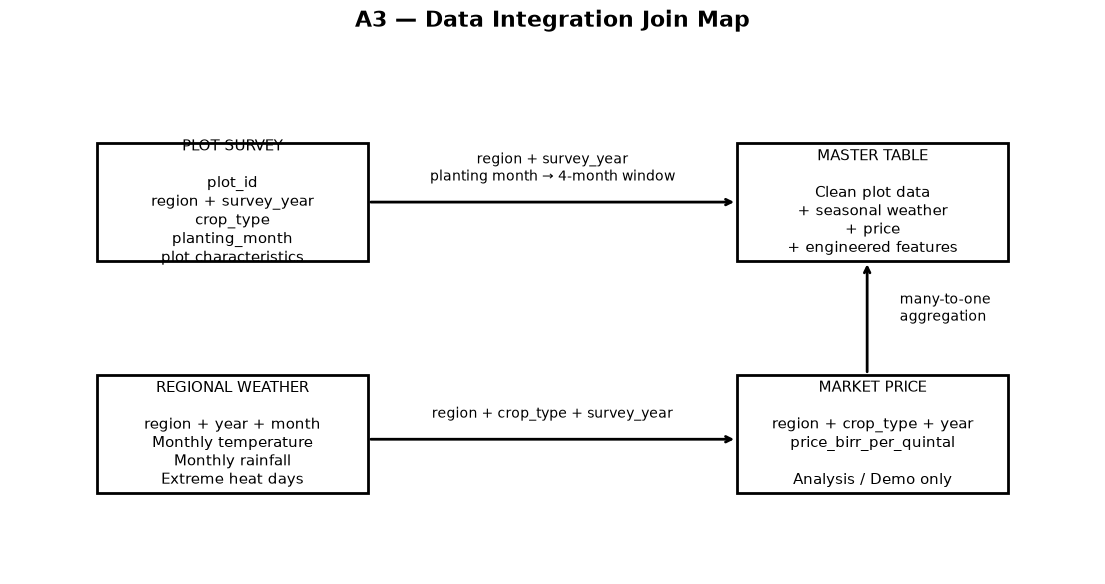

Saved: C:\Users\Administrator\Desktop\team_adwa\reports\join_map.png


In [45]:
fig, ax = plt.subplots(figsize=(14, 7))

ax.axis("off")

boxes = {
    "plot": (0.08, 0.58, 0.25, 0.22),
    "weather": (0.08, 0.15, 0.25, 0.22),
    "price": (0.67, 0.15, 0.25, 0.22),
    "master": (0.67, 0.58, 0.25, 0.22),
}

for name, (x, y, w, h) in boxes.items():

    labels = {
        "plot": (
            "PLOT SURVEY\n\n"
            "plot_id\n"
            "region + survey_year\n"
            "crop_type\n"
            "planting_month\n"
            "plot characteristics"
        ),
        "weather": (
            "REGIONAL WEATHER\n\n"
            "region + year + month\n"
            "Monthly temperature\n"
            "Monthly rainfall\n"
            "Extreme heat days"
        ),
        "price": (
            "MARKET PRICE\n\n"
            "region + crop_type + year\n"
            "price_birr_per_quintal\n\n"
            "Analysis / Demo only"
        ),
        "master": (
            "MASTER TABLE\n\n"
            "Clean plot data\n"
            "+ seasonal weather\n"
            "+ price\n"
            "+ engineered features"
        ),
    }

    ax.add_patch(
        plt.Rectangle(
            (x, y),
            w,
            h,
            fill=False,
            linewidth=2
        )
    )

    ax.text(
        x + w / 2,
        y + h / 2,
        labels[name],
        ha="center",
        va="center",
        fontsize=11
    )


# Plot -> Weather
ax.annotate(
    "",
    xy=(0.67, 0.69),
    xytext=(0.33, 0.69),
    arrowprops=dict(arrowstyle="->", linewidth=2)
)

ax.text(
    0.50,
    0.73,
    "region + survey_year\n"
    "planting month → 4-month window",
    ha="center",
    fontsize=10
)

# Plot -> Price
ax.annotate(
    "",
    xy=(0.67, 0.25),
    xytext=(0.33, 0.25),
    arrowprops=dict(arrowstyle="->", linewidth=2)
)

ax.text(
    0.50,
    0.29,
    "region + crop_type + survey_year",
    ha="center",
    fontsize=10
)

# Weather/price -> master
ax.annotate(
    "",
    xy=(0.79, 0.58),
    xytext=(0.79, 0.37),
    arrowprops=dict(arrowstyle="->", linewidth=2)
)

ax.text(
    0.82,
    0.47,
    "many-to-one\naggregation",
    fontsize=10
)

ax.set_title(
    "A3 — Data Integration Join Map",
    fontsize=16,
    fontweight="bold"
)

join_map_path = REPORTS_DIR / "join_map.png"

fig.savefig(
    join_map_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Saved:", join_map_path)

## A4 join audit table

In [46]:
join_audit = pd.DataFrame([
    {
        "join": "plot → weather",
        "left_rows_before": len(train_raw),
        "left_rows_after": len(train),
        "match_rate_pct": round(train_weather_match_rate * 100, 2),
        "unmatched_plots": int(
            (train_weather_features["weather_months_available"] == 0).sum()
        ),
        "incomplete_weather_seasons": train_incomplete_seasons,
        "cardinality": "many-to-one after seasonal aggregation",
        "row_count_changed": len(train_raw) != len(train),
    },
    {
        "join": "plot → price",
        "left_rows_before": len(train_raw),
        "left_rows_after": len(train),
        "match_rate_pct": round(train_price_match_rate * 100, 2),
        "unmatched_plots": int(
            (~train_price_matched).sum()
        ),
        "incomplete_weather_seasons": np.nan,
        "cardinality": "many-to-one",
        "row_count_changed": len(train_raw) != len(train),
    }
])

display(join_audit)

join_audit.to_csv(
    REPORTS_DIR / "A4_join_audit.csv",
    index=False
)

,join,left_rows_before,left_rows_after,match_rate_pct,unmatched_plots,incomplete_weather_seasons,cardinality,row_count_changed
0,plot → weather,15090,15090,100.00,0,6146.0,many-to-one after seasonal aggregation,False
1,plot → price,15090,15090,96.38,547,NaN,many-to-one,False


## A5: join proof for 3 specific plots

In [47]:
proof_plot_ids = train["plot_id"].head(3).tolist()

print("Plots selected for join proof:")
print(proof_plot_ids)

Plots selected for join proof:
['PLOT-000339', 'PLOT-007457', 'PLOT-006092']


## Display exact weather rows for proof plots

In [48]:
join_proof_rows = []

for plot_id in proof_plot_ids:

    plot_row = train[
        train["plot_id"] == plot_id
    ].iloc[0]

    region = plot_row["region"]
    year = int(plot_row["survey_year"])
    planting_month = plot_row["planting_month"]

    season_months = growing_season_months(
        planting_month
    )

    for month in season_months:

        if month is None:
            continue

        key = (region, year, month)

        if key in weather_lookup.index:

            record = weather_lookup.loc[key]

            join_proof_rows.append({
                "plot_id": plot_id,
                "region": region,
                "survey_year": year,
                "planting_month": planting_month,
                "season_month": month,
                "avg_temp_c": record["avg_temp_c"],
                "monthly_rainfall_mm": record["monthly_rainfall_mm"],
                "extreme_heat_days": record["extreme_heat_days"],
            })

join_proof = pd.DataFrame(join_proof_rows)

display(join_proof)

,plot_id,region,survey_year,planting_month,season_month,avg_temp_c,monthly_rainfall_mm,extreme_heat_days
0,PLOT-000339,Oromia,2024,Aug,Aug,19.1,185.1,0.0
1,PLOT-000339,Oromia,2024,Aug,Sep,15.1,NaN,0.0
2,PLOT-000339,Oromia,2024,Aug,Nov,19.4,20.8,0.0
3,PLOT-007457,Amhara,2023,Jun,Jun,17.0,118.5,0.0
4,PLOT-007457,Amhara,2023,Jun,Jul,14.9,244.6,0.0
5,PLOT-007457,Amhara,2023,Jun,Aug,14.5,192.8,0.0
6,PLOT-006092,Oromia,2024,Feb,Feb,18.2,78.5,0.0
7,PLOT-006092,Oromia,2024,Feb,Mar,20.1,92.5,0.0
8,PLOT-006092,Oromia,2024,Feb,Apr,20.2,55.8,0.0
9,PLOT-006092,Oromia,2024,Feb,May,18.3,68.1,0.0


## A5 season-level proof

In [49]:
season_proof = (
    join_proof
    .groupby(
        [
            "plot_id",
            "region",
            "survey_year",
            "planting_month"
        ]
    )
    .agg(
        weather_months_used=("season_month", "count"),
        season_mean_temp_c=("avg_temp_c", "mean"),
        season_rainfall_total_mm=("monthly_rainfall_mm", "sum"),
        season_extreme_heat_days=("extreme_heat_days", "sum"),
    )
    .reset_index()
)

display(season_proof)

season_proof.to_csv(
    REPORTS_DIR / "A5_join_proof.csv",
    index=False
)

,plot_id,region,survey_year,planting_month,weather_months_used,season_mean_temp_c,season_rainfall_total_mm,season_extreme_heat_days
0,PLOT-000339,Oromia,2024,Aug,3,17.866667,205.9,0.0
1,PLOT-006092,Oromia,2024,Feb,4,19.200000,294.9,0.0
2,PLOT-007457,Amhara,2023,Jun,3,15.466667,555.9,0.0


## A6 feature engineering table

In [50]:
feature_engineering_table = pd.DataFrame([
    {
        "feature_name": "season_mean_temp_c",
        "formula": "mean(monthly avg_temp_c over planting month + next 3 months)",
        "source_columns": "regional_weather.avg_temp_c",
        "source_table": "regional_weather.csv",
        "reason": "Captures average growing-season thermal conditions."
    },
    {
        "feature_name": "season_rainfall_total_mm",
        "formula": "sum(monthly_rainfall_mm over growing season)",
        "source_columns": "regional_weather.monthly_rainfall_mm",
        "source_table": "regional_weather.csv",
        "reason": "Represents accumulated seasonal rainfall."
    },
    {
        "feature_name": "season_extreme_heat_days",
        "formula": "sum(extreme_heat_days over growing season)",
        "source_columns": "regional_weather.extreme_heat_days",
        "source_table": "regional_weather.csv",
        "reason": "Captures heat stress exposure."
    },
    {
        "feature_name": "season_temp_std_c",
        "formula": "std(monthly avg_temp_c over growing season)",
        "source_columns": "regional_weather.avg_temp_c",
        "source_table": "regional_weather.csv",
        "reason": "Captures temperature variability during crop development."
    },
    {
        "feature_name": "season_temp_deviation_c",
        "formula": "season_mean_temp_c - training region typical seasonal temperature",
        "source_columns": "season_mean_temp_c, region",
        "source_table": "derived from plot + weather",
        "reason": "Measures whether the season was unusually warm/cool for the region."
    },
    {
        "feature_name": "fertilizer_improved_seed_interaction",
        "formula": "fertilizer_kg_per_ha × improved_seed_used",
        "source_columns": "fertilizer_kg_per_ha, improved_seed_used",
        "source_table": "plot survey",
        "reason": "Captures the combined effect of fertilizer and improved seed."
    },
    {
        "feature_name": "planting_month_num",
        "formula": "calendar month number",
        "source_columns": "planting_month",
        "source_table": "plot survey",
        "reason": "Allows the model to represent planting-time effects."
    },
    {
        "feature_name": "rainfall_per_fertilizer",
        "formula": "season_rainfall_total_mm / (fertilizer_kg_per_ha + 1)",
        "source_columns": "season_rainfall_total_mm, fertilizer_kg_per_ha",
        "source_table": "derived",
        "reason": "Represents rainfall availability relative to fertilizer investment."
    },
])

display(feature_engineering_table)

feature_engineering_table.to_csv(
    REPORTS_DIR / "A6_feature_engineering_table.csv",
    index=False
)

,feature_name,formula,source_columns,source_table,reason
0,season_mean_temp_c,mean(monthly avg_temp_c over planting month + ...,regional_weather.avg_temp_c,regional_weather.csv,Captures average growing-season thermal condit...
1,season_rainfall_total_mm,sum(monthly_rainfall_mm over growing season),regional_weather.monthly_rainfall_mm,regional_weather.csv,Represents accumulated seasonal rainfall.
2,season_extreme_heat_days,sum(extreme_heat_days over growing season),regional_weather.extreme_heat_days,regional_weather.csv,Captures heat stress exposure.
3,season_temp_std_c,std(monthly avg_temp_c over growing season),regional_weather.avg_temp_c,regional_weather.csv,Captures temperature variability during crop d...
4,season_temp_deviation_c,season_mean_temp_c - training region typical s...,"season_mean_temp_c, region",derived from plot + weather,Measures whether the season was unusually warm...
5,fertilizer_improved_seed_interaction,fertilizer_kg_per_ha × improved_seed_used,"fertilizer_kg_per_ha, improved_seed_used",plot survey,Captures the combined effect of fertilizer and...
6,planting_month_num,calendar month number,planting_month,plot survey,Allows the model to represent planting-time ef...
7,rainfall_per_fertilizer,season_rainfall_total_mm / (fertilizer_kg_per_...,"season_rainfall_total_mm, fertilizer_kg_per_ha",derived,Represents rainfall availability relative to f...


## Final master-column definition

In [51]:
base_plot_features = [
    "plot_id",
    "region",
    "crop_type",
    "survey_year",
    "planting_month",
    "altitude_m",
    "rainfall_mm_season",
    "farm_size_ha",
    "fertilizer_kg_per_ha",
    "improved_seed_used",
    "pest_disease_flag",
    "soil_quality_index",
    "labor_days_per_ha",
    "distance_to_market_km",
]

weather_features = [
    "season_mean_temp_c",
    "season_rainfall_total_mm",
    "season_extreme_heat_days",
    "season_temp_std_c",
    "season_temp_deviation_c",
    "weather_months_available",
    "weather_months_expected",
    "weather_months_missing",
]

engineered_features = [
    "planting_month_num",
    "fertilizer_improved_seed_interaction",
    "rainfall_per_fertilizer",
]

analysis_demo_features = [
    "price_birr_per_quintal",
]

target_column = "yield_tons_per_ha"

MASTER_FEATURE_COLUMNS = (
    base_plot_features
    + weather_features
    + engineered_features
    + analysis_demo_features
)

MASTER_TRAIN_COLUMNS = (
    MASTER_FEATURE_COLUMNS
    + [target_column]
)

MASTER_TEST_COLUMNS = MASTER_FEATURE_COLUMNS.copy()

print("Number of master feature columns:", len(MASTER_FEATURE_COLUMNS))
print("Train columns:", len(MASTER_TRAIN_COLUMNS))
print("Test columns:", len(MASTER_TEST_COLUMNS))

Number of master feature columns: 26
Train columns: 27
Test columns: 26


## Construct master tables

In [52]:
master_train = train[MASTER_TRAIN_COLUMNS].copy()
master_test = test[MASTER_TEST_COLUMNS].copy()

print("MASTER TRAIN:", master_train.shape)
print("MASTER TEST:", master_test.shape)

display(master_train.head())
display(master_test.head())

MASTER TRAIN: (15090, 27)
MASTER TEST: (3750, 26)


,plot_id,region,crop_type,survey_year,planting_month,altitude_m,rainfall_mm_season,farm_size_ha,fertilizer_kg_per_ha,improved_seed_used,...,season_temp_std_c,season_temp_deviation_c,weather_months_available,weather_months_expected,weather_months_missing,planting_month_num,fertilizer_improved_seed_interaction,rainfall_per_fertilizer,price_birr_per_quintal,yield_tons_per_ha
0,PLOT-000339,Oromia,barley,2024.0,Aug,2697.817349,1157.403560,0.867604,29.393684,0.0,...,1.960159,-1.030858,3,4,1,8,0.000000,6.774434,4590.0,2.209711
1,PLOT-007457,Amhara,maize,2023.0,Jun,1523.350141,897.420122,1.099197,16.843992,1.0,...,1.096459,-1.293787,3,4,1,6,16.843992,31.153343,4230.0,3.363254
2,PLOT-006092,Oromia,wheat,2024.0,Feb,2389.441948,1119.155741,0.811309,41.015144,0.0,...,0.951315,0.302476,4,4,0,2,0.000000,7.018898,5387.0,3.560614
3,PLOT-004128,SNNPR,barley,2022.0,Aug,2612.483420,1246.462210,1.602312,14.353759,0.0,...,1.294942,-0.697975,4,4,0,8,0.000000,25.941530,4181.0,1.924800
4,PLOT-003033,Amhara,sorghum,2021.0,Jul,1210.095040,928.477088,0.937758,33.736138,1.0,...,1.481741,-0.327120,3,4,1,7,33.736138,16.800947,2706.0,4.171220


,plot_id,region,crop_type,survey_year,planting_month,altitude_m,rainfall_mm_season,farm_size_ha,fertilizer_kg_per_ha,improved_seed_used,...,season_extreme_heat_days,season_temp_std_c,season_temp_deviation_c,weather_months_available,weather_months_expected,weather_months_missing,planting_month_num,fertilizer_improved_seed_interaction,rainfall_per_fertilizer,price_birr_per_quintal
0,PLOT-017296,Oromia,barley,2024.0,Jul,3001.571120,848.763828,0.790898,24.985712,1.0,...,0.0,1.633673,-1.830858,3,4,1,7,24.985712,15.039034,4590.0
1,PLOT-017259,Amhara,sorghum,2024.0,Feb,1584.992004,853.355836,2.355841,31.193783,0.0,...,0.0,0.784219,1.339546,4,4,0,2,0.000000,7.091431,34.0
2,PLOT-016178,Amhara,maize,2021.0,Mar,2025.148308,523.300456,1.529366,31.108711,1.0,...,1.0,1.256981,0.339546,4,4,0,3,31.108711,13.927684,2403.0
3,PLOT-018610,Tigray,sorghum,2021.0,Jul,1815.562220,698.343470,2.536753,127.684861,0.0,...,0.0,1.281492,-1.073287,3,4,1,7,0.000000,2.879904,2723.0
4,PLOT-015109,SNNPR,sorghum,2023.0,Jun,1324.962032,838.892045,47.269739,9.185735,0.0,...,0.0,0.895824,-1.472975,4,4,0,6,0.000000,75.193392,3493.0


## Train/test feature comparison

In [53]:
train_features_without_target = [
    col
    for col in master_train.columns
    if col != target_column
]

test_features = list(master_test.columns)

print(
    "Train/test feature columns identical:",
    train_features_without_target == test_features
)

assert train_features_without_target == test_features, (
    "Train and test feature columns do not match."
)

Train/test feature columns identical: True


## A7 integrity-check framework

In [54]:
integrity_results = []


def run_check(check_name, condition, details=""):
    passed = bool(condition)

    integrity_results.append({
        "check": check_name,
        "status": "PASS" if passed else "FAIL",
        "details": details,
    })

    symbol = "PASS" if passed else "FAIL"

    print(f"[{symbol}] {check_name}")

    if details:
        print(f"       {details}")

    return passed

## Integrity checks

In [55]:
run_check(
    "Train plot_id is unique",
    master_train["plot_id"].is_unique,
    f"Unique IDs: {master_train['plot_id'].nunique()} / {len(master_train)}"
)

run_check(
    "Test plot_id is unique",
    master_test["plot_id"].is_unique,
    f"Unique IDs: {master_test['plot_id'].nunique()} / {len(master_test)}"
)

run_check(
    "Train row count preserved",
    len(master_train) == len(train_raw.drop_duplicates()),
    f"Original after exact-duplicate removal: {len(train_raw.drop_duplicates())}; master: {len(master_train)}"
)

run_check(
    "Test row count preserved",
    len(master_test) == len(test_raw.drop_duplicates()),
    f"Original after exact-duplicate removal: {len(test_raw.drop_duplicates())}; master: {len(master_test)}"
)

run_check(
    "Train regions valid",
    set(master_train["region"].dropna()).issubset(ALLOWED_REGIONS),
    f"Regions: {sorted(master_train['region'].dropna().unique())}"
)

run_check(
    "Test regions valid",
    set(master_test["region"].dropna()).issubset(ALLOWED_REGIONS),
    f"Regions: {sorted(master_test['region'].dropna().unique())}"
)

run_check(
    "Train crops valid",
    set(master_train["crop_type"].dropna()).issubset(ALLOWED_CROPS),
    f"Crops: {sorted(master_train['crop_type'].dropna().unique())}"
)

run_check(
    "Test crops valid",
    set(master_test["crop_type"].dropna()).issubset(ALLOWED_CROPS),
    f"Crops: {sorted(master_test['crop_type'].dropna().unique())}"
)

run_check(
    "No missing model features in train",
    master_train[MASTER_FEATURE_COLUMNS].isna().sum().sum() == 0,
    f"Missing cells: {master_train[MASTER_FEATURE_COLUMNS].isna().sum().sum()}"
)

run_check(
    "No missing model features in test",
    master_test[MASTER_FEATURE_COLUMNS].isna().sum().sum() == 0,
    f"Missing cells: {master_test[MASTER_FEATURE_COLUMNS].isna().sum().sum()}"
)

run_check(
    "Train target is non-negative",
    (master_train[target_column] >= 0).all(),
    f"Minimum yield: {master_train[target_column].min()}"
)

run_check(
    "Price is positive",
    (master_train["price_birr_per_quintal"] > 0).all()
    and (master_test["price_birr_per_quintal"] > 0).all(),
    "All joined price values are positive."
)

run_check(
    "Train/test feature schemas match",
    train_features_without_target == test_features,
    "Test contains the same master feature columns as train excluding target."
)

run_check(
    "Weather feature exists",
    len(weather_features) >= 3,
    f"Weather-derived features: {weather_features}"
)

[PASS] Train plot_id is unique
       Unique IDs: 15090 / 15090
[PASS] Test plot_id is unique
       Unique IDs: 3750 / 3750
[PASS] Train row count preserved
       Original after exact-duplicate removal: 15090; master: 15090
[PASS] Test row count preserved
       Original after exact-duplicate removal: 3750; master: 3750
[PASS] Train regions valid
       Regions: ['Amhara', 'Oromia', 'SNNPR', 'Somali', 'Tigray']
[PASS] Test regions valid
       Regions: ['Amhara', 'Oromia', 'SNNPR', 'Somali', 'Tigray']
[PASS] Train crops valid
       Crops: ['barley', 'maize', 'sorghum', 'teff', 'wheat']
[PASS] Test crops valid
       Crops: ['barley', 'maize', 'sorghum', 'teff', 'wheat']
[PASS] No missing model features in train
       Missing cells: 0
[PASS] No missing model features in test
       Missing cells: 0
[PASS] Train target is non-negative
       Minimum yield: 0.1
[PASS] Price is positive
       All joined price values are positive.
[PASS] Train/test feature schemas match
       Test con

True

## Display integrity report

In [56]:
integrity_df = pd.DataFrame(integrity_results)

display(integrity_df)

integrity_df.to_csv(
    REPORTS_DIR / "A7_integrity_checks.csv",
    index=False
)

failed_checks = integrity_df[
    integrity_df["status"] == "FAIL"
]

print("\nFailed checks:", len(failed_checks))

if not failed_checks.empty:
    display(failed_checks)

,check,status,details
0,Train plot_id is unique,PASS,Unique IDs: 15090 / 15090
1,Test plot_id is unique,PASS,Unique IDs: 3750 / 3750
2,Train row count preserved,PASS,Original after exact-duplicate removal: 15090;...
3,Test row count preserved,PASS,Original after exact-duplicate removal: 3750; ...
4,Train regions valid,PASS,"Regions: ['Amhara', 'Oromia', 'SNNPR', 'Somali..."
5,Test regions valid,PASS,"Regions: ['Amhara', 'Oromia', 'SNNPR', 'Somali..."
6,Train crops valid,PASS,"Crops: ['barley', 'maize', 'sorghum', 'teff', ..."
7,Test crops valid,PASS,"Crops: ['barley', 'maize', 'sorghum', 'teff', ..."
8,No missing model features in train,PASS,Missing cells: 0
9,No missing model features in test,PASS,Missing cells: 0



Failed checks: 0


## A1 final cleaning log

In [57]:
cleaning_log_df = show_cleaning_log()

display(cleaning_log_df)

cleaning_log_df.to_csv(
    REPORTS_DIR / "A1_cleaning_log.csv",
    index=False
)

,file,columns,issue_type,rows_affected,percent_affected,fix_applied,why
0,crop_yield_train.csv,"survey_year, altitude_m, rainfall_mm_season, f...",sentinel values (-999),788,5.222,Converted -999 to NaN before validation/imputa...,"-999 is a missing-value sentinel, not a valid ..."
1,crop_yield_train.csv + crop_yield_leaderboard_...,"region, crop_type, planting_month",inconsistent categorical labels,125,0.663,Trimmed/lowercased labels and mapped known ali...,Required identical category labels across trai...
2,market_prices.csv,"region, crop_type",inconsistent categorical labels,0,0.000,Standardized region and crop labels.,Required reliable price joins.
3,regional_weather.csv,"region, year, month, avg_temp_c, monthly_rainf...",duplicate rows,1,0.431,Removed exact duplicate rows.,Duplicate records can distort aggregation and ...
4,regional_weather.csv,"region, year, month",duplicate weather keys,10,4.329,Aggregated duplicate readings by mean for nume...,The weather join requires one region/year/mont...
5,regional_weather.csv,"region, month",inconsistent categorical labels,19,8.190,Standardized region and month labels.,Required reliable region/year/month weather jo...


## Verify A1 minimum issue coverage

In [58]:
plot_log = cleaning_log_df[
    cleaning_log_df["file"].str.contains(
        "crop_yield",
        case=False,
        na=False
    )
]

weather_log = cleaning_log_df[
    cleaning_log_df["file"].str.contains(
        "weather",
        case=False,
        na=False
    )
]

price_log = cleaning_log_df[
    cleaning_log_df["file"].str.contains(
        "price",
        case=False,
        na=False
    )
]

print(
    "Distinct plot issue types:",
    plot_log["issue_type"].nunique()
)

print(
    "Distinct weather issue types:",
    weather_log["issue_type"].nunique()
)

print(
    "Distinct price issue types:",
    price_log["issue_type"].nunique()
)

display(plot_log)
display(weather_log)
display(price_log)

Distinct plot issue types: 2
Distinct weather issue types: 3
Distinct price issue types: 1


,file,columns,issue_type,rows_affected,percent_affected,fix_applied,why
0,crop_yield_train.csv,"survey_year, altitude_m, rainfall_mm_season, f...",sentinel values (-999),788,5.222,Converted -999 to NaN before validation/imputa...,"-999 is a missing-value sentinel, not a valid ..."
1,crop_yield_train.csv + crop_yield_leaderboard_...,"region, crop_type, planting_month",inconsistent categorical labels,125,0.663,Trimmed/lowercased labels and mapped known ali...,Required identical category labels across trai...


,file,columns,issue_type,rows_affected,percent_affected,fix_applied,why
3,regional_weather.csv,"region, year, month, avg_temp_c, monthly_rainf...",duplicate rows,1,0.431,Removed exact duplicate rows.,Duplicate records can distort aggregation and ...
4,regional_weather.csv,"region, year, month",duplicate weather keys,10,4.329,Aggregated duplicate readings by mean for nume...,The weather join requires one region/year/mont...
5,regional_weather.csv,"region, month",inconsistent categorical labels,19,8.190,Standardized region and month labels.,Required reliable region/year/month weather jo...


,file,columns,issue_type,rows_affected,percent_affected,fix_applied,why
2,market_prices.csv,"region, crop_type",inconsistent categorical labels,0,0.0,Standardized region and crop labels.,Required reliable price joins.


## A2 final standardization proof

In [59]:
standardization_proof = pd.DataFrame([
    {
        "table": "plot_train",
        "field": "region",
        "unique_after": sorted(train["region"].dropna().unique().tolist()),
        "allowed_set_match": set(train["region"].dropna()).issubset(ALLOWED_REGIONS),
    },
    {
        "table": "plot_test",
        "field": "region",
        "unique_after": sorted(test["region"].dropna().unique().tolist()),
        "allowed_set_match": set(test["region"].dropna()).issubset(ALLOWED_REGIONS),
    },
    {
        "table": "weather",
        "field": "region",
        "unique_after": sorted(weather["region"].dropna().unique().tolist()),
        "allowed_set_match": set(weather["region"].dropna()).issubset(ALLOWED_REGIONS),
    },
    {
        "table": "price",
        "field": "region",
        "unique_after": sorted(prices["region"].dropna().unique().tolist()),
        "allowed_set_match": set(prices["region"].dropna()).issubset(ALLOWED_REGIONS),
    },
    {
        "table": "plot_train",
        "field": "crop_type",
        "unique_after": sorted(train["crop_type"].dropna().unique().tolist()),
        "allowed_set_match": set(train["crop_type"].dropna()).issubset(ALLOWED_CROPS),
    },
    {
        "table": "plot_test",
        "field": "crop_type",
        "unique_after": sorted(test["crop_type"].dropna().unique().tolist()),
        "allowed_set_match": set(test["crop_type"].dropna()).issubset(ALLOWED_CROPS),
    },
    {
        "table": "price",
        "field": "crop_type",
        "unique_after": sorted(prices["crop_type"].dropna().unique().tolist()),
        "allowed_set_match": set(prices["crop_type"].dropna()).issubset(ALLOWED_CROPS),
    },
])

display(standardization_proof)

standardization_proof.to_csv(
    REPORTS_DIR / "A2_standardization_proof.csv",
    index=False
)

,table,field,unique_after,allowed_set_match
0,plot_train,region,"[Amhara, Oromia, SNNPR, Somali, Tigray]",True
1,plot_test,region,"[Amhara, Oromia, SNNPR, Somali, Tigray]",True
2,weather,region,"[Amhara, Oromia, SNNPR, Somali, Tigray]",True
3,price,region,"[Amhara, Oromia, SNNPR, Somali, Tigray]",True
4,plot_train,crop_type,"[barley, maize, sorghum, teff, wheat]",True
5,plot_test,crop_type,"[barley, maize, sorghum, teff, wheat]",True
6,price,crop_type,"[barley, maize, sorghum, teff, wheat]",True


## A8. Data dictionary

In [60]:
data_dictionary = pd.DataFrame([
    {
        "column": "plot_id",
        "type": "string",
        "source_file": "crop_yield_train/test.csv",
        "description": "Unique plot identifier.",
        "derivation": "Original plot identifier."
    },
    {
        "column": "region",
        "type": "categorical",
        "source_file": "crop_yield_train/test.csv",
        "description": "Ethiopian region.",
        "derivation": "Standardized region labels."
    },
    {
        "column": "crop_type",
        "type": "categorical",
        "source_file": "crop_yield_train/test.csv",
        "description": "Crop type.",
        "derivation": "Standardized crop labels."
    },
    {
        "column": "survey_year",
        "type": "integer",
        "source_file": "crop_yield_train/test.csv",
        "description": "Survey year.",
        "derivation": "Original survey year."
    },
    {
        "column": "planting_month",
        "type": "categorical",
        "source_file": "crop_yield_train/test.csv",
        "description": "Crop planting month.",
        "derivation": "Standardized month label."
    },
    {
        "column": "altitude_m",
        "type": "numeric",
        "source_file": "crop_yield_train/test.csv",
        "description": "Elevation above sea level in meters.",
        "derivation": "Cleaned original feature."
    },
    {
        "column": "rainfall_mm_season",
        "type": "numeric",
        "source_file": "crop_yield_train/test.csv",
        "description": "Plot-reported seasonal rainfall.",
        "derivation": "Cleaned original feature."
    },
    {
        "column": "farm_size_ha",
        "type": "numeric",
        "source_file": "crop_yield_train/test.csv",
        "description": "Farm size in hectares.",
        "derivation": "Cleaned original feature."
    },
    {
        "column": "fertilizer_kg_per_ha",
        "type": "numeric",
        "source_file": "crop_yield_train/test.csv",
        "description": "Fertilizer applied per hectare.",
        "derivation": "Cleaned original feature."
    },
    {
        "column": "improved_seed_used",
        "type": "binary",
        "source_file": "crop_yield_train/test.csv",
        "description": "Whether improved seed was used.",
        "derivation": "Cleaned original feature."
    },
    {
        "column": "pest_disease_flag",
        "type": "binary",
        "source_file": "crop_yield_train/test.csv",
        "description": "Observed pest/disease pressure.",
        "derivation": "Cleaned original feature."
    },
    {
        "column": "soil_quality_index",
        "type": "numeric",
        "source_file": "crop_yield_train/test.csv",
        "description": "Soil quality index from 0 to 1.",
        "derivation": "Cleaned original feature."
    },
    {
        "column": "labor_days_per_ha",
        "type": "numeric",
        "source_file": "crop_yield_train/test.csv",
        "description": "Labor-days invested per hectare.",
        "derivation": "Cleaned original feature."
    },
    {
        "column": "distance_to_market_km",
        "type": "numeric",
        "source_file": "crop_yield_train/test.csv",
        "description": "Distance to nearest market in kilometers.",
        "derivation": "Cleaned original feature."
    },
    {
        "column": "season_mean_temp_c",
        "type": "numeric",
        "source_file": "regional_weather.csv",
        "description": "Mean temperature during growing season.",
        "derivation": "Mean of planting month plus following three months."
    },
    {
        "column": "season_rainfall_total_mm",
        "type": "numeric",
        "source_file": "regional_weather.csv",
        "description": "Total rainfall during growing season.",
        "derivation": "Sum of monthly rainfall over growing season."
    },
    {
        "column": "season_extreme_heat_days",
        "type": "numeric",
        "source_file": "regional_weather.csv",
        "description": "Total extreme heat days during growing season.",
        "derivation": "Sum over growing-season months."
    },
    {
        "column": "season_temp_std_c",
        "type": "numeric",
        "source_file": "regional_weather.csv",
        "description": "Temperature variability during growing season.",
        "derivation": "Standard deviation of monthly temperature."
    },
    {
        "column": "season_temp_deviation_c",
        "type": "numeric",
        "source_file": "regional_weather.csv + plot",
        "description": "Seasonal temperature deviation from the region's training baseline.",
        "derivation": "Season mean temperature minus training-region seasonal mean."
    },
    {
        "column": "weather_months_available",
        "type": "integer",
        "source_file": "regional_weather.csv",
        "description": "Number of weather months found in the growing-season window.",
        "derivation": "Count of matched monthly weather records."
    },
    {
        "column": "weather_months_expected",
        "type": "integer",
        "source_file": "derived",
        "description": "Expected growing-season months.",
        "derivation": "Fixed at four months."
    },
    {
        "column": "weather_months_missing",
        "type": "integer",
        "source_file": "derived",
        "description": "Missing months from the four-month growing-season window.",
        "derivation": "Expected months minus available months."
    },
    {
        "column": "planting_month_num",
        "type": "integer",
        "source_file": "plot survey",
        "description": "Numeric calendar representation of planting month.",
        "derivation": "Jan=1 through Dec=12."
    },
    {
        "column": "fertilizer_improved_seed_interaction",
        "type": "numeric",
        "source_file": "plot survey",
        "description": "Interaction between fertilizer and improved seed usage.",
        "derivation": "fertilizer_kg_per_ha × improved_seed_used."
    },
    {
        "column": "rainfall_per_fertilizer",
        "type": "numeric",
        "source_file": "derived",
        "description": "Seasonal rainfall relative to fertilizer investment.",
        "derivation": "season rainfall / (fertilizer + 1)."
    },
    {
        "column": "price_birr_per_quintal",
        "type": "numeric",
        "source_file": "market_prices.csv",
        "description": "Market price in Ethiopian birr per quintal.",
        "derivation": "Joined by region + crop + year; analysis/demo only, not a yield-model feature."
    },
    {
        "column": "yield_tons_per_ha",
        "type": "numeric target",
        "source_file": "crop_yield_train.csv",
        "description": "Observed crop yield in tons per hectare.",
        "derivation": "Training target; absent from test."
    },
])

display(data_dictionary)

data_dictionary.to_csv(
    PROCESSED_DIR / "data_dictionary_master.csv",
    index=False
)

,column,type,source_file,description,derivation
0,plot_id,string,crop_yield_train/test.csv,Unique plot identifier.,Original plot identifier.
1,region,categorical,crop_yield_train/test.csv,Ethiopian region.,Standardized region labels.
2,crop_type,categorical,crop_yield_train/test.csv,Crop type.,Standardized crop labels.
3,survey_year,integer,crop_yield_train/test.csv,Survey year.,Original survey year.
4,planting_month,categorical,crop_yield_train/test.csv,Crop planting month.,Standardized month label.
5,altitude_m,numeric,crop_yield_train/test.csv,Elevation above sea level in meters.,Cleaned original feature.
6,rainfall_mm_season,numeric,crop_yield_train/test.csv,Plot-reported seasonal rainfall.,Cleaned original feature.
7,farm_size_ha,numeric,crop_yield_train/test.csv,Farm size in hectares.,Cleaned original feature.
8,fertilizer_kg_per_ha,numeric,crop_yield_train/test.csv,Fertilizer applied per hectare.,Cleaned original feature.
9,improved_seed_used,binary,crop_yield_train/test.csv,Whether improved seed was used.,Cleaned original feature.


## Export master tables

In [61]:
MASTER_TRAIN_PATH = PROCESSED_DIR / "master_train.csv"
MASTER_TEST_PATH = PROCESSED_DIR / "master_test.csv"

master_train.to_csv(
    MASTER_TRAIN_PATH,
    index=False
)

master_test.to_csv(
    MASTER_TEST_PATH,
    index=False
)

print("Saved:")
print(MASTER_TRAIN_PATH)
print(MASTER_TEST_PATH)
print(PROCESSED_DIR / "data_dictionary_master.csv")

Saved:
C:\Users\Administrator\Desktop\team_adwa\data\processed\master_train.csv
C:\Users\Administrator\Desktop\team_adwa\data\processed\master_test.csv
C:\Users\Administrator\Desktop\team_adwa\data\processed\data_dictionary_master.csv


## Final export verification

In [62]:
saved_train = pd.read_csv(MASTER_TRAIN_PATH)
saved_test = pd.read_csv(MASTER_TEST_PATH)
saved_dictionary = pd.read_csv(
    PROCESSED_DIR / "data_dictionary_master.csv"
)

print("Saved train:", saved_train.shape)
print("Saved test:", saved_test.shape)
print("Saved dictionary:", saved_dictionary.shape)

assert list(saved_train.columns) == MASTER_TRAIN_COLUMNS

assert list(saved_test.columns) == MASTER_TEST_COLUMNS

assert (
    list(saved_train.columns[:-1])
    == list(saved_test.columns)
)

assert saved_train["plot_id"].is_unique
assert saved_test["plot_id"].is_unique

assert saved_train[target_column].notna().all()
assert saved_test[target_column if target_column in saved_test.columns else "plot_id"].notna().all()

print("\nFINAL EXPORT CHECK: PASS")

Saved train: (15090, 27)
Saved test: (3750, 26)
Saved dictionary: (27, 5)

FINAL EXPORT CHECK: PASS


## Generate A report automatically

In [63]:
report_path = REPORTS_DIR / "A_cleaning_and_integration.md"

report_lines = []

report_lines.append("# A — Data Cleaning & Integration Report\n")
report_lines.append("## Qiyas Ethiopian Smallholder Crop-Yield Challenge\n")

report_lines.append("## A1 — Cleaning Log\n")
report_lines.append(
    cleaning_log_df.to_markdown(index=False)
    if not cleaning_log_df.empty
    else "No cleaning issues were detected."
)

report_lines.append("\n## A2 — Key Standardization Proof\n")
report_lines.append(
    standardization_proof.to_markdown(index=False)
)

report_lines.append("\n## A3 — Join Map\n")
report_lines.append(
    "Join diagram saved at `reports/join_map.png`."
)

report_lines.append(
    "\nGrowing-season rule: planting month plus the following three months, "
    "using weather observations for the plot's survey year. "
    "Incomplete windows are recorded in the join audit."
)

report_lines.append("\n## A4 — Join Audit\n")
report_lines.append(
    join_audit.to_markdown(index=False)
)

report_lines.append("\n## A5 — Join Proof\n")
report_lines.append(
    season_proof.to_markdown(index=False)
)

report_lines.append("\n## A6 — Feature Engineering\n")
report_lines.append(
    feature_engineering_table.to_markdown(index=False)
)

report_lines.append("\n## A7 — Integrity Checks\n")
report_lines.append(
    integrity_df.to_markdown(index=False)
)

report_lines.append("\n## A8 — Master Tables\n")
report_lines.append(
    f"- `data/processed/master_train.csv`: {len(master_train):,} rows\n"
)

report_lines.append(
    f"- `data/processed/master_test.csv`: {len(master_test):,} rows\n"
)

report_lines.append(
    "- `data/processed/data_dictionary_master.csv`\n"
)

report_lines.append(
    "\n### Model hygiene\n"
    "- Weather-derived features are included in the master tables.\n"
    "- Market price is included for analysis/demo only and must not be used as a yield-model feature.\n"
    "- Train-derived statistics are used for plot-level and weather-feature imputation.\n"
    "- Raw files are never modified.\n"
)

report_path.write_text(
    "\n".join(report_lines),
    encoding="utf-8"
)

print("Saved:", report_path)

Saved: C:\Users\Administrator\Desktop\team_adwa\reports\A_cleaning_and_integration.md


## Final A checklist

In [64]:
final_checks = {
    "A1 cleaning log": (REPORTS_DIR / "A1_cleaning_log.csv").exists(),
    "A2 standardization proof": (REPORTS_DIR / "A2_standardization_proof.csv").exists(),
    "A3 join map": (REPORTS_DIR / "join_map.png").exists(),
    "A4 join audit": (REPORTS_DIR / "A4_join_audit.csv").exists(),
    "A5 join proof": (REPORTS_DIR / "A5_join_proof.csv").exists(),
    "A6 feature table": (REPORTS_DIR / "A6_feature_engineering_table.csv").exists(),
    "A7 integrity checks": (REPORTS_DIR / "A7_integrity_checks.csv").exists(),
    "A8 master_train": MASTER_TRAIN_PATH.exists(),
    "A8 master_test": MASTER_TEST_PATH.exists(),
    "A8 data dictionary": (
        PROCESSED_DIR / "data_dictionary_master.csv"
    ).exists(),
    "A report": report_path.exists(),
}

final_check_df = pd.DataFrame([
    {
        "Deliverable": key,
        "Status": "PASS" if value else "FAIL"
    }
    for key, value in final_checks.items()
])

display(final_check_df)

if not all(final_checks.values()):
    raise AssertionError(
        "One or more Deliverable A outputs are missing."
    )

if not failed_checks.empty:
    raise AssertionError(
        "One or more A7 integrity checks failed."
    )

print("=" * 80)
print("DELIVERABLE A COMPLETE")
print("=" * 80)

,Deliverable,Status
0,A1 cleaning log,PASS
1,A2 standardization proof,PASS
2,A3 join map,PASS
3,A4 join audit,PASS
4,A5 join proof,PASS
5,A6 feature table,PASS
6,A7 integrity checks,PASS
7,A8 master_train,PASS
8,A8 master_test,PASS
9,A8 data dictionary,PASS


DELIVERABLE A COMPLETE
